# CleanGanga — Notebook 02: Pollution Hotspot Analysis + ML Baseline

## Objective

This notebook continues from **Notebook 01: Data Quality & EDA**.

Notebook 01 already handled:
- Dataset loading and Prayagraj/Allahabad filtering
- Data-quality and missing-value analysis
- Duplicate checking
- Descriptive statistics
- Exploratory Data Analysis (EDA)
- Environmental threshold definitions
- Rule-based observation-level pollution assessment

**Those steps are not repeated here.**

This notebook focuses on:

**Observation assessment → Station aggregation → Persistence → Severity → Trend → Anomaly detection → Transparent hotspot score → Hotspot ranking → ML baseline**

### Engineering principle

We build the simplest transparent baseline first, measure it, inspect its limitations, and only then add AI components such as IBM Granite, RAG, and IBM BOB.

> Important: the rule-based `Pollution_Level` from Notebook 01 is derived from BOD and Fecal Coliform. Therefore, current BOD/FC values must not be used as direct ML features when predicting that label, otherwise target leakage occurs.

## 1. Load the Prepared Assessment Data

Notebook 01 exports the prepared observation-level assessment dataset.

Expected path:

`data/prayagraj_assessment.csv`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ASSESSMENT_PATH = Path("../data/prayagraj_assessment.csv")

assessment_df = pd.read_csv(ASSESSMENT_PATH)

assessment_df["Data Acquisition Time"] = pd.to_datetime(
    assessment_df["Data Acquisition Time"],
    errors="coerce"
)

print("Prepared assessment data loaded.")
print("Shape:", assessment_df.shape)

Prepared assessment data loaded.
Shape: (107, 25)


## 2. Validate Required Columns

Fail early if the prepared dataset does not contain the fields required by this notebook.

In [2]:
required_columns = [
    "Station",
    "Data Acquisition Time",
    "Latitude",
    "Longitude",
    "Biochemical Oxygen Demand (mg/L)",
    "Fecal Coliform (MPN/100mL)",
    "BOD_exceeds",
    "FC_above_desirable",
    "FC_exceeds_maximum",
    "Pollution_Level"
]

missing_required = [
    column for column in required_columns
    if column not in assessment_df.columns
]

if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("All required columns are present.")

All required columns are present.


## 3. Observation-Level Pollution Classification

Notebook 01 already created the rule-based `Pollution_Level`.

We use that existing assessment rather than creating a second classification rule.

This keeps Notebook 02 focused on station-level analysis.

In [3]:
print("Pollution level distribution:")
print(assessment_df["Pollution_Level"].value_counts())

Pollution level distribution:
Pollution_Level
Moderate Pollution    100
Low Pollution           7
Name: count, dtype: int64


## 4. Quantify Observation Severity

Severity measures how far a measurement is from the selected reference threshold.

We retain separate BOD and Fecal Coliform exceedance measures so that the final hotspot score remains interpretable.

In [4]:
BOD_LIMIT = 3.0
FC_DESIRABLE = 500.0
FC_MAXIMUM = 2500.0

assessment_df["BOD_ratio"] = (
    assessment_df["Biochemical Oxygen Demand (mg/L)"] / BOD_LIMIT
)

assessment_df["FC_ratio"] = (
    assessment_df["Fecal Coliform (MPN/100mL)"] / FC_DESIRABLE
)

assessment_df["BOD_exceedance"] = np.maximum(
    assessment_df["BOD_ratio"] - 1,
    0
)

assessment_df["FC_exceedance"] = np.maximum(
    assessment_df["FC_ratio"] - 1,
    0
)

display(
    assessment_df[
        [
            "Station",
            "Biochemical Oxygen Demand (mg/L)",
            "Fecal Coliform (MPN/100mL)",
            "BOD_ratio",
            "FC_ratio",
            "Pollution_Level"
        ]
    ].head(10)
)

,Station,Biochemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),BOD_ratio,FC_ratio,Pollution_Level
0,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.0,790.0,0.666667,1.58,Moderate Pollution
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,1300.0,0.866667,2.60,Moderate Pollution
2,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,930.0,0.866667,1.86,Moderate Pollution
3,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.5,1100.0,0.833333,2.20,Moderate Pollution
4,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1200.0,0.900000,2.40,Moderate Pollution
5,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.8,1400.0,0.933333,2.80,Moderate Pollution
6,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1300.0,0.900000,2.60,Moderate Pollution
7,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.7,1100.0,0.900000,2.20,Moderate Pollution
8,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.6,1200.0,0.866667,2.40,Moderate Pollution
9,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,2.8,1200.0,0.933333,2.40,Moderate Pollution


## 5. Station-Level Summary

A hotspot represents a location-level pattern rather than one isolated observation.

We aggregate measurements and threshold signals by station.

In [5]:
station_summary = (
    assessment_df
    .groupby("Station")
    .agg(
        observations=("Station", "size"),
        mean_bod=("Biochemical Oxygen Demand (mg/L)", "mean"),
        max_bod=("Biochemical Oxygen Demand (mg/L)", "max"),
        mean_fc=("Fecal Coliform (MPN/100mL)", "mean"),
        max_fc=("Fecal Coliform (MPN/100mL)", "max"),
        bod_exceedances=("BOD_exceeds", "sum"),
        fc_desirable_exceedances=("FC_above_desirable", "sum"),
        fc_max_exceedances=("FC_exceeds_maximum", "sum"),
        mean_bod_exceedance=("BOD_exceedance", "mean"),
        mean_fc_exceedance=("FC_exceedance", "mean"),
        latitude=("Latitude", "first"),
        longitude=("Longitude", "first")
    )
    .reset_index()
)

display(station_summary)

,Station,observations,mean_bod,max_bod,mean_fc,max_fc,bod_exceedances,fc_desirable_exceedances,fc_max_exceedances,mean_bod_exceedance,mean_fc_exceedance,latitude,longitude
0,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,23,2.734783,2.9,1003.913043,1400.0,0,23,0,0.0,1.007826,25.502474,81.855439
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,23,2.665217,2.9,1011.739130,1400.0,0,23,0,0.0,1.023478,25.419206,81.900522
2,GANGA AT KADAGHAT ALLAHABAD,22,2.659091,2.9,960.909091,1400.0,0,22,0,0.0,0.921818,25.443124,81.887148
3,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,23,2.621739,2.8,792.173913,1100.0,0,23,0,0.0,0.584348,25.259363,82.096478
4,TONS AT CHAKGHAT M.P.,5,1.740000,2.0,2.000000,2.0,0,0,0,0.0,0.000000,25.043083,81.721004
5,YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P,11,2.545455,2.7,654.545455,930.0,0,9,0,0.0,0.320000,25.422471,81.838806


## 6. Pollution Persistence

Persistence measures how consistently a station shows pollution-related signals.

**Persistence = pollution-positive observations / total observations**

An observation is pollution-positive when either BOD exceeds its limit or Fecal Coliform exceeds its desirable reference.

In [6]:
assessment_df["pollution_positive"] = (
    assessment_df["BOD_exceeds"]
    | assessment_df["FC_above_desirable"]
)

persistence_summary = (
    assessment_df
    .groupby("Station")
    .agg(
        polluted_observations=("pollution_positive", "sum")
    )
    .reset_index()
)

station_summary = station_summary.merge(
    persistence_summary,
    on="Station",
    how="left"
)

station_summary["persistence"] = (
    station_summary["polluted_observations"]
    / station_summary["observations"]
)

display(
    station_summary[
        [
            "Station",
            "observations",
            "polluted_observations",
            "persistence"
        ]
    ].sort_values("persistence", ascending=False)
)

,Station,observations,polluted_observations,persistence
0,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,23,23,1.000000
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,23,23,1.000000
2,GANGA AT KADAGHAT ALLAHABAD,22,22,1.000000
3,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,23,23,1.000000
5,YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P,11,9,0.818182
4,TONS AT CHAKGHAT M.P.,5,0,0.000000


## 7. Station-Level Severity

Persistence tells us how often pollution occurs.

Severity tells us how strongly the measurements depart from the reference thresholds.

In [7]:
severity_summary = (
    assessment_df
    .groupby("Station")
    .agg(
        mean_bod_ratio=("BOD_ratio", "mean"),
        max_bod_ratio=("BOD_ratio", "max"),
        mean_fc_ratio=("FC_ratio", "mean"),
        max_fc_ratio=("FC_ratio", "max")
    )
    .reset_index()
)

station_summary = station_summary.merge(
    severity_summary,
    on="Station",
    how="left"
)

display(
    station_summary[
        [
            "Station",
            "mean_bod_ratio",
            "max_bod_ratio",
            "mean_fc_ratio",
            "max_fc_ratio",
            "mean_bod_exceedance",
            "mean_fc_exceedance"
        ]
    ]
)

,Station,mean_bod_ratio,max_bod_ratio,mean_fc_ratio,max_fc_ratio,mean_bod_exceedance,mean_fc_exceedance
0,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,0.911594,0.966667,2.007826,2.800,0.0,1.007826
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,0.888406,0.966667,2.023478,2.800,0.0,1.023478
2,GANGA AT KADAGHAT ALLAHABAD,0.886364,0.966667,1.921818,2.800,0.0,0.921818
3,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,0.873913,0.933333,1.584348,2.200,0.0,0.584348
4,TONS AT CHAKGHAT M.P.,0.580000,0.666667,0.004000,0.004,0.0,0.000000
5,YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P,0.848485,0.900000,1.309091,1.860,0.0,0.320000


## 8. Temporal Trend Analysis

For each station, we calculate a simple slope over observation order.

A positive slope suggests an increasing measurement trend; a negative slope suggests a decreasing trend.

The slope is descriptive and does not establish causation.

In [8]:
trend_rows = []

for station, group in assessment_df.groupby("Station"):
    group = group.sort_values("Data Acquisition Time").dropna(
        subset=[
            "Data Acquisition Time",
            "Biochemical Oxygen Demand (mg/L)",
            "Fecal Coliform (MPN/100mL)"
        ]
    )

    if len(group) < 2:
        trend_rows.append({
            "Station": station,
            "bod_trend": np.nan,
            "fc_trend": np.nan
        })
        continue

    x = np.arange(len(group))

    trend_rows.append({
        "Station": station,
        "bod_trend": np.polyfit(
            x,
            group["Biochemical Oxygen Demand (mg/L)"],
            1
        )[0],
        "fc_trend": np.polyfit(
            x,
            group["Fecal Coliform (MPN/100mL)"],
            1
        )[0]
    })

trend_summary = pd.DataFrame(trend_rows)

station_summary = station_summary.merge(
    trend_summary,
    on="Station",
    how="left"
)

display(
    station_summary[
        ["Station", "bod_trend", "fc_trend"]
    ]
)

,Station,bod_trend,fc_trend
0,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,0.090000,-2.800000e+01
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,0.074286,-2.971429e+01
2,GANGA AT KADAGHAT ALLAHABAD,0.150000,-1.470000e+02
3,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,0.110000,-8.600000e+01
4,TONS AT CHAKGHAT M.P.,-0.040000,-3.149852e-16
5,YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P,NaN,NaN


## 9. Observation-Level Anomaly Detection

A threshold exceedance is not the same as an anomaly.

- Threshold: is the measurement above an environmental reference?
- Anomaly: is the measurement unusually different from the station's own historical behavior?

We use a simple station-level z-score as a baseline anomaly detector.

In [9]:
for column, z_column in [
    ("Biochemical Oxygen Demand (mg/L)", "BOD_zscore"),
    ("Fecal Coliform (MPN/100mL)", "FC_zscore")
]:
    group_mean = assessment_df.groupby("Station")[column].transform("mean")
    group_std = assessment_df.groupby("Station")[column].transform("std")

    assessment_df[z_column] = (
        (assessment_df[column] - group_mean)
        / group_std.replace(0, np.nan)
    )

assessment_df["anomaly"] = (
    assessment_df["BOD_zscore"].abs().ge(2)
    | assessment_df["FC_zscore"].abs().ge(2)
)

print("Anomalous observations:", int(assessment_df["anomaly"].sum()))

Anomalous observations: 7


## 10. Station-Level Anomaly Rate

In [10]:
anomaly_summary = (
    assessment_df
    .groupby("Station")
    .agg(
        anomalous_observations=("anomaly", "sum"),
        anomaly_rate=("anomaly", "mean")
    )
    .reset_index()
)

station_summary = station_summary.merge(
    anomaly_summary,
    on="Station",
    how="left"
)

display(
    station_summary[
        ["Station", "anomalous_observations", "anomaly_rate"]
    ].sort_values("anomaly_rate", ascending=False)
)

,Station,anomalous_observations,anomaly_rate
5,YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P,2,0.181818
2,GANGA AT KADAGHAT ALLAHABAD,2,0.090909
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,1,0.043478
0,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,1,0.043478
3,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,1,0.043478
4,TONS AT CHAKGHAT M.P.,0,0.000000


## 11. Build a Transparent Baseline Hotspot Score

We combine three interpretable signals:

1. **Persistence** — repeated pollution-related observations.
2. **Severity** — magnitude of threshold departure.
3. **Anomaly rate** — unusual observations relative to station history.

Each signal is scaled to 0–1.

The first experiment uses equal weights.

This is a transparent baseline, not a final scientific weighting scheme.

In [11]:
def min_max_scale(series):
    series = series.astype(float)
    min_value = series.min()
    max_value = series.max()

    if pd.isna(min_value) or pd.isna(max_value):
        return pd.Series(0.0, index=series.index)

    if max_value == min_value:
        return pd.Series(0.0, index=series.index)

    return (series - min_value) / (max_value - min_value)


station_summary["persistence_score"] = min_max_scale(
    station_summary["persistence"]
)

station_summary["severity_raw"] = (
    station_summary["mean_bod_exceedance"].fillna(0)
    + station_summary["mean_fc_exceedance"].fillna(0)
)

station_summary["severity_score"] = min_max_scale(
    station_summary["severity_raw"]
)

station_summary["anomaly_score"] = min_max_scale(
    station_summary["anomaly_rate"].fillna(0)
)

station_summary["hotspot_score_baseline"] = (
    station_summary["persistence_score"]
    + station_summary["severity_score"]
    + station_summary["anomaly_score"]
) / 3

hotspots = station_summary.sort_values(
    "hotspot_score_baseline",
    ascending=False
).reset_index(drop=True)

## 12. Rank the Potential Hotspots

The ranking is a decision-support output.

A high score means the station combines stronger evidence across the baseline signals. It does not prove that the station is the source of pollution.

In [12]:
top_hotspots = hotspots[
    [
        "Station",
        "latitude",
        "longitude",
        "observations",
        "persistence",
        "mean_bod",
        "mean_fc",
        "anomaly_rate",
        "hotspot_score_baseline"
    ]
].head(10)

display(top_hotspots)

,Station,latitude,longitude,observations,persistence,mean_bod,mean_fc,anomaly_rate,hotspot_score_baseline
0,GANGA AT KADAGHAT ALLAHABAD,25.443124,81.887148,22,1.000000,2.659091,960.909091,0.090909,0.800224
1,GANGA AT ALLAHABAD D/S (SANGAM) U.P.,25.419206,81.900522,23,1.000000,2.665217,1011.739130,0.043478,0.746377
2,GANGA AT ALLAHABAD (RASOOLABAD) U.P.,25.502474,81.855439,23,1.000000,2.734783,1003.913043,0.043478,0.741279
3,YAMUNA AT ALLAHABAD D/S (BALUA GHAT) U.P,25.422471,81.838806,11,0.818182,2.545455,654.545455,0.181818,0.710280
4,RIVER GANGA A/C TAMSA RIVER SIRSA SON BARSA,25.259363,82.096478,23,1.000000,2.621739,792.173913,0.043478,0.603358
5,TONS AT CHAKGHAT M.P.,25.043083,81.721004,5,0.000000,1.740000,2.000000,0.000000,0.000000


## 13. Visualize the Baseline Hotspot Ranking

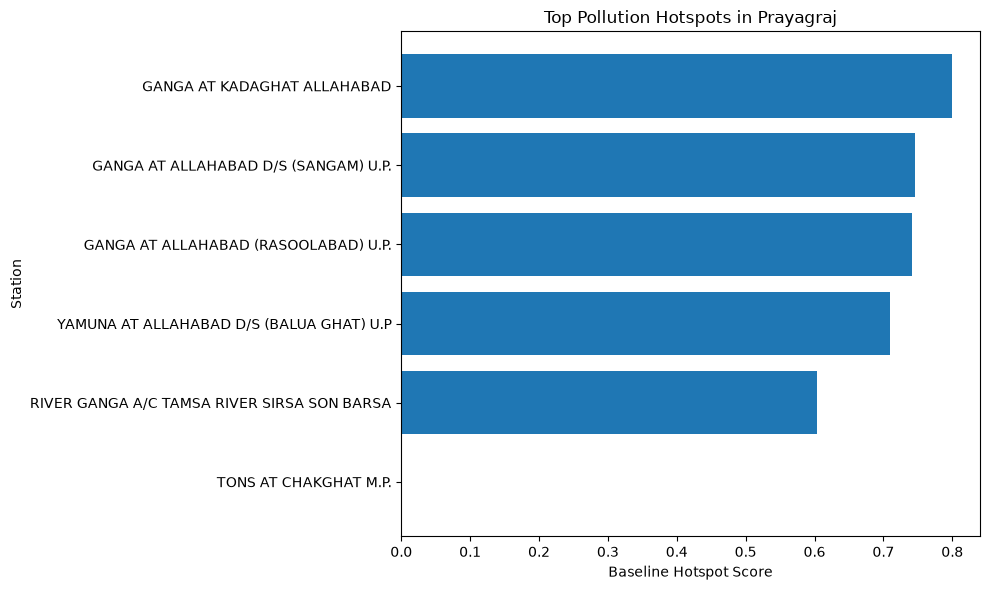

In [13]:
plot_data = hotspots.head(10).sort_values(
    "hotspot_score_baseline"
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Station"].astype(str),
    plot_data["hotspot_score_baseline"]
)

plt.xlabel("Baseline Hotspot Score")
plt.ylabel("Station")
plt.title("Top Pollution Hotspots in Prayagraj")
plt.tight_layout()
plt.show()

## 14. Inspect the Highest-Ranked Station

A ranking should be supported by the underlying observation history.

In [14]:
if not hotspots.empty:
    top_station = hotspots.iloc[0]["Station"]

    top_station_history = (
        assessment_df[
            assessment_df["Station"] == top_station
        ]
        .sort_values("Data Acquisition Time")
    )

    display(
        top_station_history[
            [
                "Data Acquisition Time",
                "Biochemical Oxygen Demand (mg/L)",
                "Fecal Coliform (MPN/100mL)",
                "Pollution_Level",
                "anomaly"
            ]
        ]
    )

,Data Acquisition Time,Biochemical Oxygen Demand (mg/L),Fecal Coliform (MPN/100mL),Pollution_Level,anomaly
46,2021-04-01 08:30:00,2.0,1300.0,Moderate Pollution,True
50,2021-07-03 08:30:00,2.8,1300.0,Moderate Pollution,False
52,2021-08-04 08:30:00,2.6,780.0,Moderate Pollution,False
54,2021-10-05 08:30:00,2.5,810.0,Moderate Pollution,False
67,2021-12-12 08:30:00,2.9,810.0,Moderate Pollution,False
47,NaT,2.7,1000.0,Moderate Pollution,False
48,NaT,2.7,1100.0,Moderate Pollution,False
49,NaT,2.8,1400.0,Moderate Pollution,True
51,NaT,2.6,1300.0,Moderate Pollution,False
53,NaT,2.7,680.0,Moderate Pollution,False


## 15. Baseline Findings

Record findings from the actual notebook output:

- Top-ranked station(s)
- Persistence
- Mean/max BOD and Fecal Coliform
- Anomaly rate
- Observation count
- Missing-data limitations

Do not claim that the ranking proves causation or permanent pollution.

## 16. ML Readiness Decision

Before using machine learning, we check the target carefully.

### Target

Notebook 01 created:

`Pollution_Level`

This is a **rule-based environmental assessment** derived from BOD and Fecal Coliform.

### Target leakage warning

We must **not** use the current BOD or Fecal Coliform measurement as an input feature to predict `Pollution_Level`, because those same measurements helped create the label.

Therefore, the first ML experiment uses only information that is not the current measurement used to construct the label:

- Latitude
- Longitude
- Month
- Observation order within the dataset

This is intentionally a modest baseline.

If its predictive performance is weak, that is a useful engineering result rather than a failure: it tells us that location/time alone is insufficient to predict the rule-based assessment.

### Why Logistic Regression?

Logistic Regression is chosen as the first ML baseline because:
- the target is categorical,
- it is simple and fast,
- its coefficients are interpretable,
- it provides probabilities/confidence,
- it gives us a transparent baseline before trying more complex models.

We should not assume that it will be the best model.

## 17. Prepare the ML Dataset

In [15]:
ml_df = assessment_df[
    [
        "Station",
        "Data Acquisition Time",
        "Latitude",
        "Longitude",
        "Pollution_Level"
    ]
].copy()

ml_df["month"] = ml_df["Data Acquisition Time"].dt.month
ml_df["observation_order"] = (
    ml_df.sort_values("Data Acquisition Time")
         .groupby("Station")
         .cumcount()
)

ml_df = ml_df.dropna(
    subset=[
        "Latitude",
        "Longitude",
        "month",
        "observation_order",
        "Pollution_Level"
    ]
)

features = [
    "Latitude",
    "Longitude",
    "month",
    "observation_order"
]

X = ml_df[features]
y = ml_df["Pollution_Level"]

print("Features:", features)
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features: ['Latitude', 'Longitude', 'month', 'observation_order']
Feature shape: (27, 4)
Target shape: (27,)

Target distribution:
Pollution_Level
Moderate Pollution    22
Low Pollution          5
Name: count, dtype: int64


## 18. Train-Test Split

We use a stratified split so that the class proportions are approximately preserved.

Because the dataset is small and imbalanced, the final evaluation should be interpreted cautiously.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 21
Testing samples: 6


## 19. Feature Scaling

Latitude, longitude, month, and observation order are on different numerical scales.

Standardization puts them on a comparable scale before Logistic Regression.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 20. Logistic Regression Baseline

This is our first classical ML model.

The goal is not to make the model unnecessarily complex. The goal is to establish a measurable baseline that we can compare against later approaches.

In [18]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 21. Evaluate the ML Baseline

We report accuracy, precision, recall, and F1-score.

Because the target classes are imbalanced, accuracy alone is not sufficient.

Accuracy: 1.000

Classification Report:
                    precision    recall  f1-score   support

     Low Pollution       1.00      1.00      1.00         1
Moderate Pollution       1.00      1.00      1.00         5

          accuracy                           1.00         6
         macro avg       1.00      1.00      1.00         6
      weighted avg       1.00      1.00      1.00         6



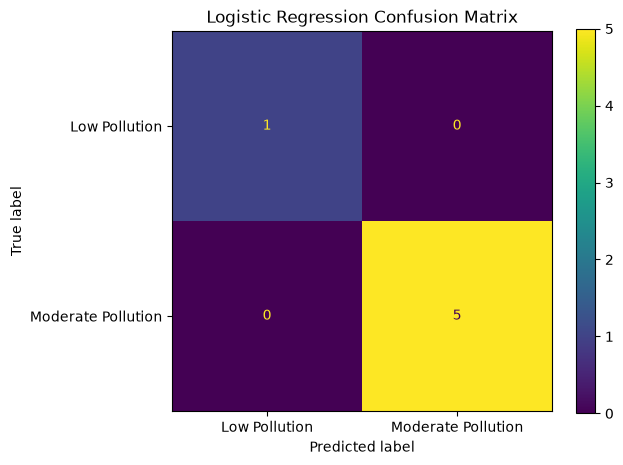

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

y_pred = logistic_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=logistic_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## 22. Interpret the Logistic Regression Model

The coefficients show how the standardized features influence the model's class decisions.

They should be interpreted as model associations, not causal environmental relationships.

In [21]:
# Examine Logistic Regression coefficients

coefficient_table = pd.DataFrame(
    logistic_model.coef_,
    columns=features,
    index=[f"Class: {logistic_model.classes_[1]}"]
)

display(coefficient_table)

,Latitude,Longitude,month,observation_order
Class: Moderate Pollution,1.494496,1.102882,0.065552,-0.000796


In [22]:
# Export station-level analysis results for Notebook 3

station_summary.to_csv(
    "../data/station_summary.csv",
    index=False
)

hotspots.to_csv(
    "../data/hotspot_ranking.csv",
    index=False
)

print("Export completed successfully.")
print("Created:")
print("../data/station_summary.csv")
print("../data/hotspot_ranking.csv")

Export completed successfully.
Created:
../data/station_summary.csv
../data/hotspot_ranking.csv


## 23. ML Baseline Conclusion

Record the **actual measured results** after running the model.

Answer:

1. What accuracy did Logistic Regression achieve?
2. Which class had the weakest recall?
3. Did the model perform better than a simple majority-class baseline?
4. Which features had the strongest coefficients?
5. What limitations arise from the small dataset and rule-derived target?

### Important interpretation

If Logistic Regression performs poorly, we should not hide that result.

A weak baseline can show that:
- location/time information alone is insufficient,
- the dataset is too small for reliable generalization,
- the rule-based target may not be a suitable independent ML ground truth.

That finding helps determine whether a more sophisticated ML approach is justified.

## 24. Next AI Layer: IBM Granite, RAG and IBM BOB

The next stage should add AI where it provides a clear capability beyond the classical baseline.

### IBM Granite

Use Granite for grounded explanation and summarization, for example:

**Hotspot metrics + supporting evidence → Granite → human-readable explanation**

The model should not invent environmental measurements or unsupported causes.

### RAG

Build a small verified knowledge base containing relevant environmental standards, guidance, and project documentation.

Flow:

**User question → Retrieval → Relevant evidence → Granite → Answer with evidence**

### IBM BOB

Use IBM BOB as an AI-assisted development/prototyping component where appropriate. It should support the workflow rather than replace the measurable analytical baseline.

### Final architecture

**Data → Rule-based assessment → Hotspot baseline → ML baseline → Evidence retrieval → Granite explanation → Decision-support interface**

## 25. Responsible AI and Limitations

- The hotspot score is a decision-support indicator, not a regulatory judgment.
- The `Pollution_Level` target is rule-derived and should not be presented as independent scientific ground truth.
- Current BOD/FC values are excluded from the first ML feature set to avoid target leakage.
- Historical monitoring data may be incomplete or unevenly distributed.
- Small sample size limits model reliability.
- Correlation and trend do not establish causation.
- Anomaly detection identifies unusual observations but does not explain their physical cause.
- AI-generated explanations must be grounded in computed evidence and verified source documents.
- The system should communicate uncertainty rather than presenting rankings or predictions as absolute truth.

These principles align with the internship requirement to demonstrate responsible AI, including transparency, ethics, fairness, and privacy.

## 26. Reproducibility Notes

Record:
- dataset source/version,
- filtering decisions,
- threshold sources,
- feature-selection decisions,
- model configuration,
- measured evaluation results,
- limitations,
- AI/RAG experiments.

Never commit API keys or other secrets to Git.

